In [1]:
# Abidul Hasib
# CAP 4630 FINAL PROJECT

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Cleaned_apartments_for_rent_classified_10k.csv to Cleaned_apartments_for_rent_classified_10k.csv


In [4]:
df_train = pd.read_csv("Cleaned_apartments_for_rent_classified_10k.csv")

##**First Training linear regression model**

In [6]:

# Separate features and target
X = df_train.drop(columns=["price"])
y = df_train["price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 349.8425428044841
Root Mean Squared Error: 945.3009846821386
R² Score: -0.0044841958792387615


## **2nd training linear regression model**

In [7]:
df_train["price"].describe()

,price
count,10000.000000
mean,1486.277500
std,1076.507968
min,200.000000
25%,949.000000
50%,1270.000000
75%,1695.000000
max,52500.000000


In [9]:
df_train.sort_values(by="price", ascending=False).head(20)

,bathrooms,bedrooms,price,square_feet,latitude,longitude,amenity_AC,amenity_Alarm,amenity_Basketball,amenity_Cable or Satellite,...,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,state_missing
8829,1.0,0.0,52500,1418,34.8870,-117.0350,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9996,8.0,6.0,25000,8716,34.4331,-119.6331,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9990,5.0,4.0,19500,5000,34.0372,-118.2972,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9972,4.0,6.0,14950,4044,34.0372,-118.2972,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8581,2.0,2.0,13500,1325,34.0630,-118.4363,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9825,3.0,3.0,13000,2530,34.0394,-118.2656,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,8.5,6.0,11000,11318,39.0287,-77.2409,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8573,2.0,2.0,11000,1322,32.6596,-117.1595,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9946,1.0,5.0,11000,3395,26.0121,-80.2453,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9227,2.0,2.0,10600,1636,34.0584,-118.4135,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
upper_limit = df_train["price"].quantile(0.99)

print("99th percentile price:", upper_limit)

df_model = df_train[df_train["price"] <= upper_limit].copy()

print("Original shape:", df_train.shape)
print("New shape:", df_model.shape)

99th percentile price: 4995.0
Original shape: (10000, 143)
New shape: (9906, 143)


In [11]:
X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 285.8412738974064
Root Mean Squared Error: 579.450742236625
R² Score: 0.35133463071707927


## **Random Forest**


In [13]:

# Use the cleaned/outlier-removed dataframe
X = df_model.drop(columns=["price"])
y = df_model["price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R² Score:", r2_rf)

Random Forest MAE: 225.06738707076937
Random Forest RMSE: 345.1967218929245
Random Forest R² Score: 0.7697916928288753


## **Gradient Boosting**

In [15]:

# Use the outlier-removed dataframe
X = df_model.drop(columns=["price"])
y = df_model["price"]

# Split data the same way as before
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R² Score:", r2_gb)

Gradient Boosting MAE: 265.1159899326357
Gradient Boosting RMSE: 387.432626797798
Gradient Boosting R² Score: 0.7100119859482787


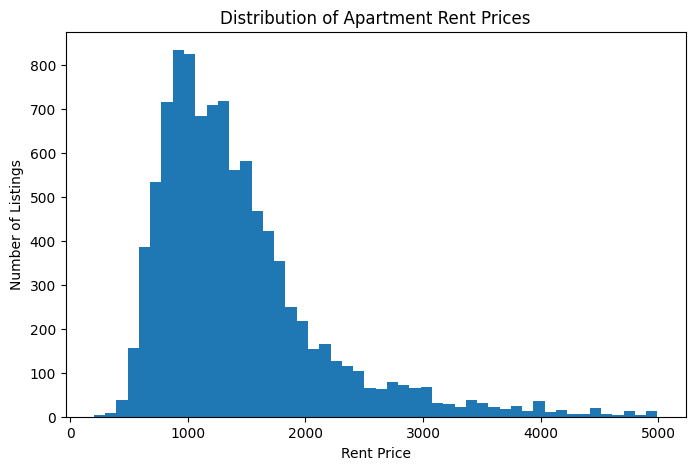

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_model["price"], bins=50)
plt.xlabel("Rent Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Apartment Rent Prices")
plt.show()

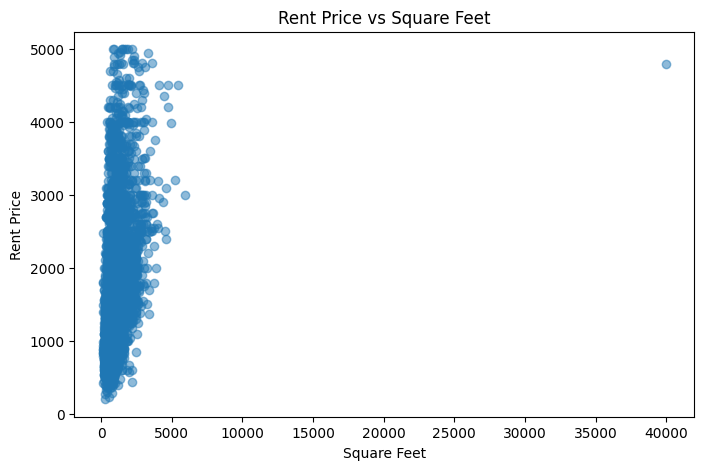

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["square_feet"], df_model["price"], alpha=0.5)
plt.xlabel("Square Feet")
plt.ylabel("Rent Price")
plt.title("Rent Price vs Square Feet")
plt.show()

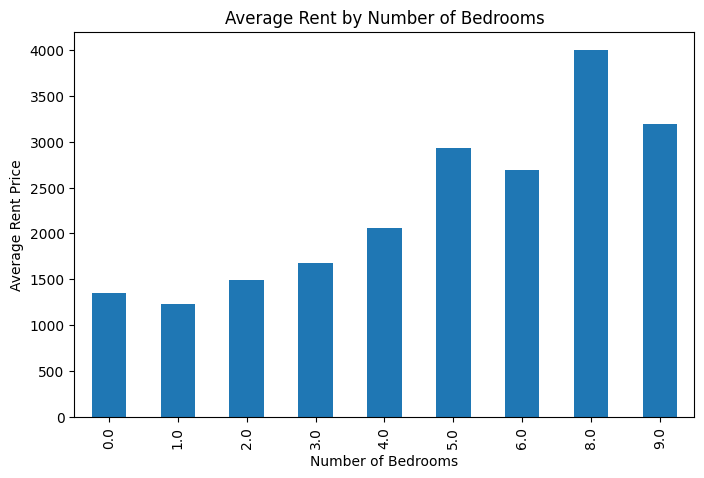

In [18]:
avg_rent_bedrooms = df_model.groupby("bedrooms")["price"].mean()

plt.figure(figsize=(8, 5))
avg_rent_bedrooms.plot(kind="bar")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Rent Price")
plt.title("Average Rent by Number of Bedrooms")
plt.show()

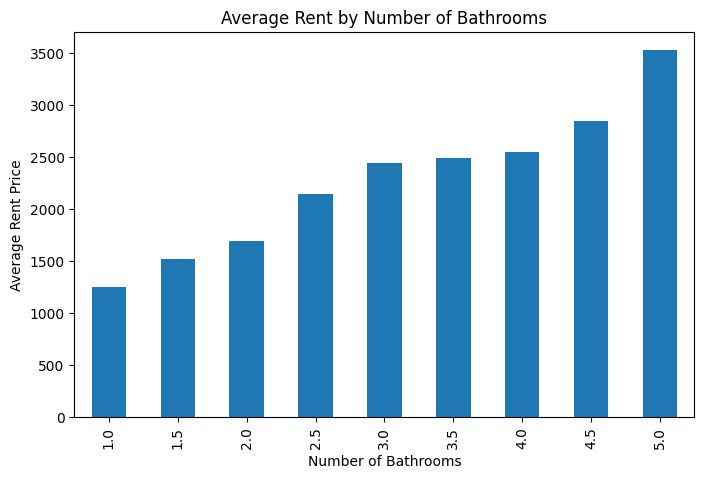

In [19]:
avg_rent_bathrooms = df_model.groupby("bathrooms")["price"].mean()

plt.figure(figsize=(8, 5))
avg_rent_bathrooms.plot(kind="bar")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Rent Price")
plt.title("Average Rent by Number of Bathrooms")
plt.show()

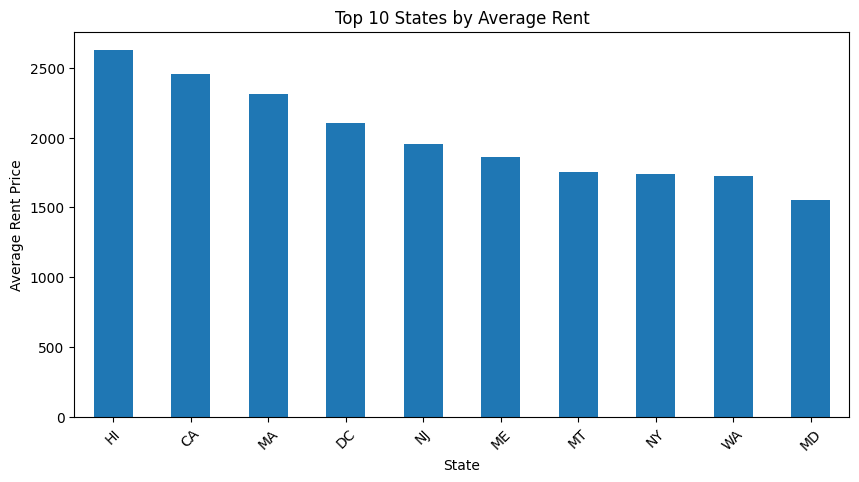

In [22]:
state_cols = [col for col in df_model.columns if col.startswith('state_')]
avg_rent_by_state = {}

for state_col in state_cols:
    # Extract the actual state abbreviation from the column name (e.g., 'state_CA' -> 'CA')
    state_name = state_col.replace('state_', '')

    # Filter rows where this specific state column is 1 and calculate the mean price
    # We also ensure the state has listings before calculating the mean
    state_df = df_model[df_model[state_col] == 1]
    if not state_df.empty:
        avg_rent_by_state[state_name] = state_df['price'].mean()

# Convert the dictionary to a pandas Series for easy sorting and plotting
avg_rent_by_state_series = pd.Series(avg_rent_by_state)

# Sort in descending order and get the top 10 states
top_states = avg_rent_by_state_series.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_states.plot(kind="bar")
plt.xlabel("State")
plt.ylabel("Average Rent Price")
plt.title("Top 10 States by Average Rent")
plt.xticks(rotation=45)
plt.show()

## **Model Comparison Visuals**

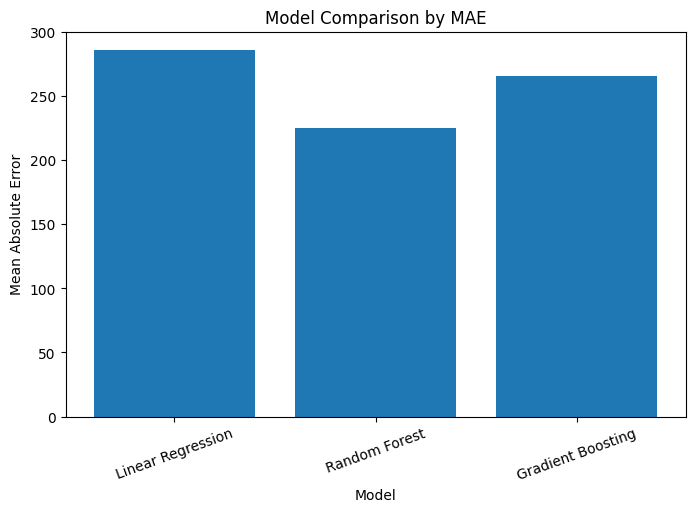

In [23]:


results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [285.84, 225.07, 265.12],
    "RMSE": [579.45, 345.20, 387.43],
    "R2 Score": [0.351, 0.770, 0.710]
})

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["MAE"])
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison by MAE")
plt.xticks(rotation=20)
plt.show()

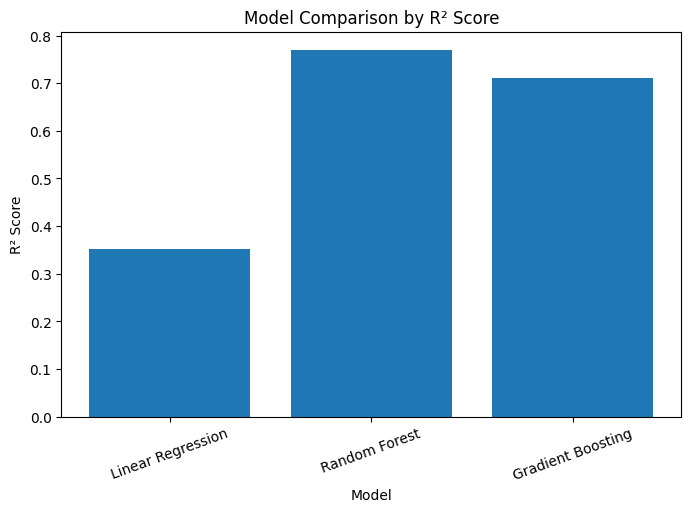

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison by R² Score")
plt.xticks(rotation=20)
plt.show()

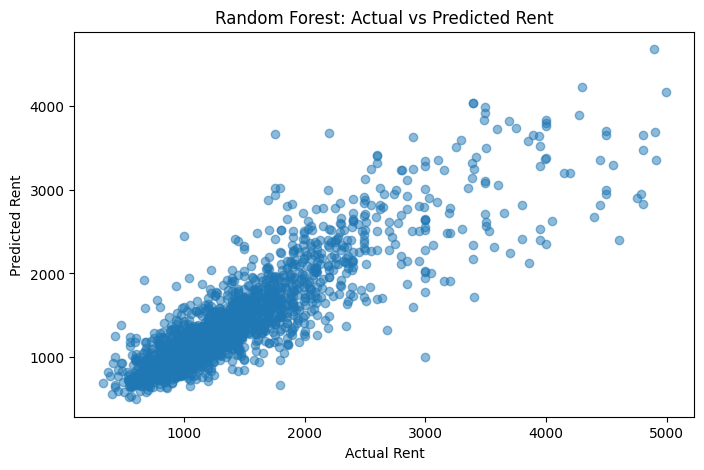

In [25]:
rf_preds = rf_model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_preds, alpha=0.5)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Random Forest: Actual vs Predicted Rent")
plt.show()

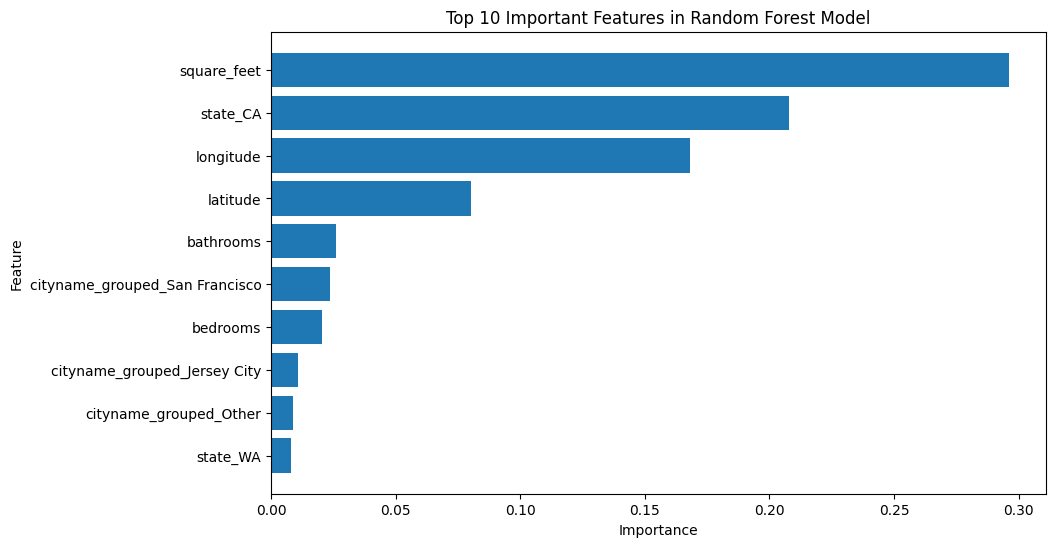

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features in Random Forest Model")
plt.gca().invert_yaxis()
plt.show()

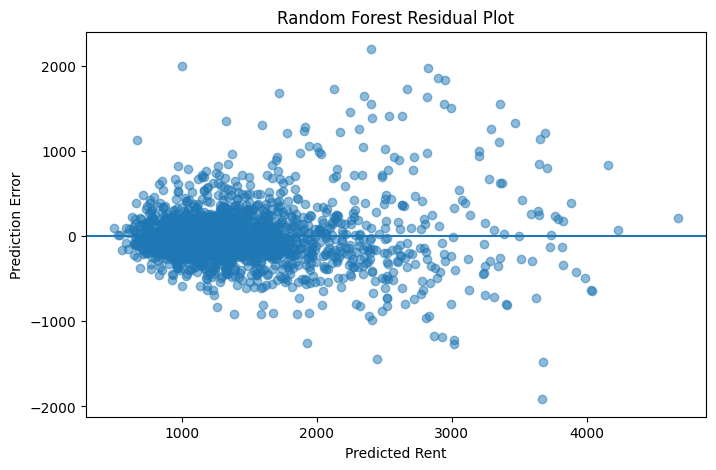

In [27]:
errors = y_test - rf_preds

plt.figure(figsize=(8, 5))
plt.scatter(rf_preds, errors, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted Rent")
plt.ylabel("Prediction Error")
plt.title("Random Forest Residual Plot")
plt.show()

In [28]:
import joblib

joblib.dump(rf_model, "rent_project_random_forest_model.pkl")

['rent_project_random_forest_model.pkl']

In [29]:
import joblib

joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [31]:
from google.colab import files

files.download("rent_project_random_forest_model.pkl")
files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>